In [1]:
# ============================================
# PHISHING EMAIL ANALYZER
# Built by Astha Patel
# ============================================

# STEP 1 - Install and import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")

# STEP 2 - Load the dataset
df = pd.read_csv('phishing_email.csv')
print(f"✅ Dataset loaded! Total emails: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head(3))

✅ Libraries loaded successfully!
✅ Dataset loaded! Total emails: 82486
Columns: ['text_combined', 'label']
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0
2  enron actuals march 30 april 1 201 estimated a...      0


=== DATASET OVERVIEW ===
Total emails: 82486

Label breakdown:
label
1    42891
0    39595
Name: count, dtype: int64

Legitimate emails: 39595
Phishing emails: 42891

Missing values: 0


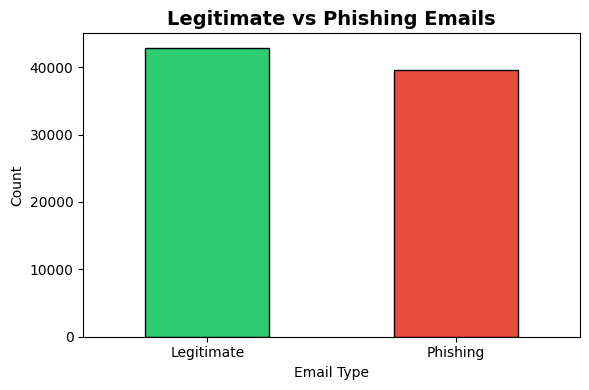

✅ Chart saved!


In [2]:
# STEP 3 - Explore the data
print("=== DATASET OVERVIEW ===")
print(f"Total emails: {len(df)}")
print(f"\nLabel breakdown:")
print(df['label'].value_counts())
print(f"\nLegitimate emails: {len(df[df['label']==0])}")
print(f"Phishing emails: {len(df[df['label']==1])}")

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Visualize the distribution
plt.figure(figsize=(6,4))
colors = ['#2ecc71', '#e74c3c']
df['label'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Legitimate vs Phishing Emails', fontsize=14, fontweight='bold')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.xticks([0, 1], ['Legitimate', 'Phishing'], rotation=0)
plt.tight_layout()
plt.savefig('email_distribution.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [3]:
# STEP 4 - Clean the data
df = df.dropna()
print(f"✅ Removed missing values. Remaining emails: {len(df)}")

# STEP 5 - Prepare data for the model
X = df['text_combined']
y = df['label']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"✅ Training emails: {len(X_train)}")
print(f"✅ Testing emails: {len(X_test)}")

# STEP 6 - Convert text to numbers (TF-IDF)
print("\n⏳ Converting emails to numbers (this takes ~30 seconds)...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("✅ Text converted successfully!")

# STEP 7 - Train the model
print("\n⏳ Training the AI model...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
print("✅ Model trained successfully!")

# STEP 8 - Test the model
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 MODEL ACCURACY: {accuracy*100:.2f}%")
print("\n=== DETAILED REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

✅ Removed missing values. Remaining emails: 82486
✅ Training emails: 65988
✅ Testing emails: 16498

⏳ Converting emails to numbers (this takes ~30 seconds)...
✅ Text converted successfully!

⏳ Training the AI model...
✅ Model trained successfully!

🎯 MODEL ACCURACY: 98.04%

=== DETAILED REPORT ===
              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98      7935
    Phishing       0.98      0.98      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



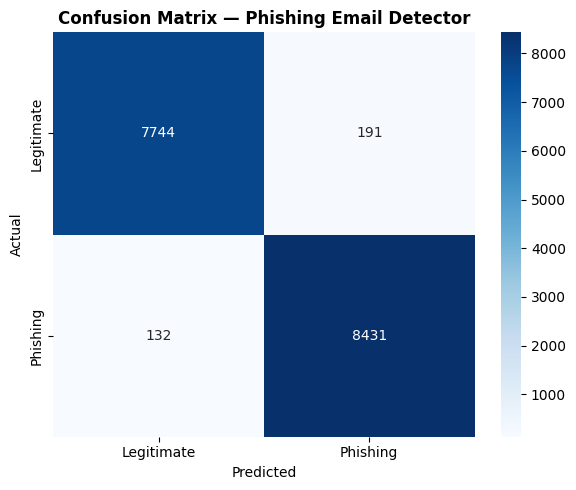

✅ Confusion matrix saved!


In [4]:
# STEP 9 - Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix — Phishing Email Detector', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

In [5]:
def analyze_email(email_text):
    email_tfidf = vectorizer.transform([email_text])
    prediction = model.predict(email_tfidf)[0]
    probability = model.predict_proba(email_tfidf)[0]
    confidence = max(probability) * 100
    if prediction == 1:
        result = "PHISHING DETECTED"
    else:
        result = "LEGITIMATE EMAIL"
    print(f"RESULT: {result} | CONFIDENCE: {confidence:.2f}%")

analyze_email("URGENT your account suspended click here enter password credit card now")
analyze_email("Hi team meeting agenda attached for tomorrow 10am best regards Sarah")
analyze_email("Congratulations you won million dollars send bank account details now")

RESULT: PHISHING DETECTED | CONFIDENCE: 99.28%
RESULT: LEGITIMATE EMAIL | CONFIDENCE: 95.02%
RESULT: PHISHING DETECTED | CONFIDENCE: 98.46%
